# Imports

In [1]:
import sys, os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

import random
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from modules.eml_loader import EmlLoader
from utils.helpers.header_cleaner import clean_header

/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Config

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

CSV_PATH = "../../datasets/processed/final_combined.csv"

DEVICE: cuda


# Load Dataset

In [3]:
df = pd.read_csv(CSV_PATH)

headers_df = df[[
    "headers_raw","canonical_raw","label",
    "header_from_reply_mismatch",
    "header_domain_mismatch",
    "header_suspicious_tld",
    "header_received_count",
    "header_to_anomaly",
    "header_x_mailer_anomaly",
    "header_date_malformed"
]].copy()

headers_df["headers_raw"] = headers_df["headers_raw"].fillna("").astype(str)
headers_df["canonical_raw"] = headers_df["canonical_raw"].fillna("").astype(str)

headers_df["headers_raw_clean"] = headers_df["headers_raw"].apply(clean_header)

# Remove empty/missing headers
headers_df["headers_raw_clean"] = headers_df["headers_raw_clean"].fillna("").astype(str)
headers_df = headers_df[headers_df["headers_raw_clean"].str.strip().astype(bool)]


def build_header_input(row):
    anomaly_text = (
        f"from_reply_mismatch: {row['header_from_reply_mismatch']} "
        f"domain_mismatch: {row['header_domain_mismatch']} "
        f"suspicious_tld: {row['header_suspicious_tld']} "
        f"received_count: {row['header_received_count']} "
        f"to_anomaly: {row['header_to_anomaly']} "
        f"x_mailer_anomaly: {row['header_x_mailer_anomaly']} "
        f"date_malformed: {row['header_date_malformed']}"
    )

    return (
        "[RAW]\n" + row["headers_raw_clean"] +
        "\n\n[CANONICAL]\n" + row["canonical_raw"] +
        "\n\n[ANOMALIES]\n" + anomaly_text
    )

headers_df["header_input"] = headers_df.apply(build_header_input, axis=1).astype(str)


# Drop duplicates
headers_df = headers_df.drop_duplicates(subset=["header_input"])

print("Header-only rows:", headers_df.shape[0])
print(headers_df["label"].value_counts(normalize=True))

train_df, val_df = train_test_split(
    headers_df,
    test_size=0.1,
    random_state=SEED,
    stratify=headers_df["label"]
)

print("Train size:", len(train_df), "Val size:", len(val_df))
print("Train label counts:", train_df["label"].value_counts())
print("Val label counts:", val_df["label"].value_counts())
print(headers_df["header_input"].head())

/tmp/ipykernel_26716/3718474810.py:1: DtypeWarning: Columns (3,4,5,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


Header-only rows: 102233
label
1    0.514423
0    0.485577
Name: proportion, dtype: float64
Train size: 92009 Val size: 10224
Train label counts: label
1    47332
0    44677
Name: count, dtype: int64
Val label counts: label
1    5259
0    4965
Name: count, dtype: int64
79044    [RAW]\nReturn-Path: <2.21043.2c-kMPmgZUD7TNG.1...
79045    [RAW]\nReturn-Path: <D-8-270241-5399979-2-2436...
79046    [RAW]\nReturn-Path: <Online#3.19976.19-ZxCpgoy...
79047    [RAW]\nReturn-Path: <michaelr@lindows.com>\nRe...
79048    [RAW]\nReturn-Path: <Online#3.20467.ac-q5A1l6t...
Name: header_input, dtype: object


# Tokenizer + Dataset

In [4]:
MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Assigned pad_token =", tokenizer.pad_token)

MAX_LEN = 512

def tokenize_headers(batch):
    out = tokenizer(
        batch["header_input"],
        truncation=True,
        max_length=MAX_LEN
    )
    numeric_cols = [
        "header_from_reply_mismatch",
        "header_domain_mismatch",
        "header_suspicious_tld",
        "header_received_count",
        "header_to_anomaly",
        "header_x_mailer_anomaly",
        "header_date_malformed"
    ]
    for col in numeric_cols:
        out[col] = batch[col]
    return out

train_ds = Dataset.from_pandas(train_df.rename(columns={"label":"labels"}))
val_ds   = Dataset.from_pandas(val_df.rename(columns={"label":"labels"}))

# remove ONLY the columns we are no longer using
train_ds_tokenized = train_ds.map(tokenize_headers, batched=True, remove_columns=["headers_raw","headers_raw_clean","canonical_raw","header_input"])
val_ds_tokenized   = val_ds.map(tokenize_headers, batched=True, remove_columns=["headers_raw","headers_raw_clean","canonical_raw","header_input"])

torch_cols = ["input_ids", "attention_mask", "labels"] + [
    "header_from_reply_mismatch",
    "header_domain_mismatch",
    "header_suspicious_tld",
    "header_received_count",
    "header_to_anomaly",
    "header_x_mailer_anomaly",
    "header_date_malformed"
]

train_ds_tokenized.set_format("torch", columns=torch_cols)
val_ds_tokenized.set_format("torch", columns=torch_cols)

data_collator = DataCollatorWithPadding(tokenizer)

/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Map: 100%|██████████| 10224/10224 [00:02<00:00, 3790.92 examples/s]


# Model

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.config.pad_token_id = tokenizer.pad_token_id
# model.gradient_checkpointing_enable()  # Gradient checkpointing
model.to(device)

print("Model loaded:", MODEL_NAME)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: microsoft/deberta-v3-base


# Metrics

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    print("\nConfusion Matrix:")
    print(confusion_matrix(labels, preds))
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# Trainning Arguments

In [7]:
training_args = TrainingArguments(
    output_dir="header_deberta_large_out",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.06,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,  # effective batch size = 16
    num_train_epochs=3,
    weight_decay=0.01,
    bf16=False,
    fp16=True,
    max_grad_norm=1.0,
    gradient_checkpointing=False,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    optim="adamw_torch",
    label_smoothing_factor=0.1,
    report_to="none",
)

# Trainer

In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

/tmp/ipykernel_26716/2193099151.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


# Train

In [9]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.203800,0.203946,0.997946,0.999618,0.996387,0.998000
2,0.204300,0.200115,0.999609,0.999620,0.999620,0.999620
3,0.203000,0.200103,0.999511,0.999620,0.999430,0.999525



Confusion Matrix:
[[4963    2]
 [  19 5240]]

Confusion Matrix:
[[4963    2]
 [   2 5257]]

Confusion Matrix:
[[4963    2]
 [   3 5256]]


TrainOutput(global_step=17253, training_loss=0.2072904457605411, metrics={'train_runtime': 22889.7464, 'train_samples_per_second': 12.059, 'train_steps_per_second': 0.754, 'total_flos': 6.644559560771901e+16, 'train_loss': 0.2072904457605411, 'epoch': 3.0})

# Save Model

In [10]:
trainer.save_model("header_deberta_large")
tokenizer.save_pretrained("header_deberta_large_tokenizer")
print("Training complete and model saved.")

Training complete and model saved.


# Confusion Matrix


Confusion Matrix:
[[4963    2]
 [   2 5257]]


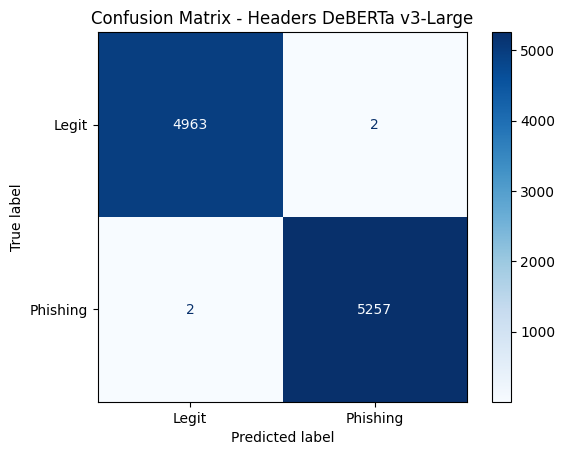

In [11]:
preds = trainer.predict(val_ds_tokenized)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(-1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Headers DeBERTa v3-Large")
plt.show()

# Loss Curve & Metrics Curve

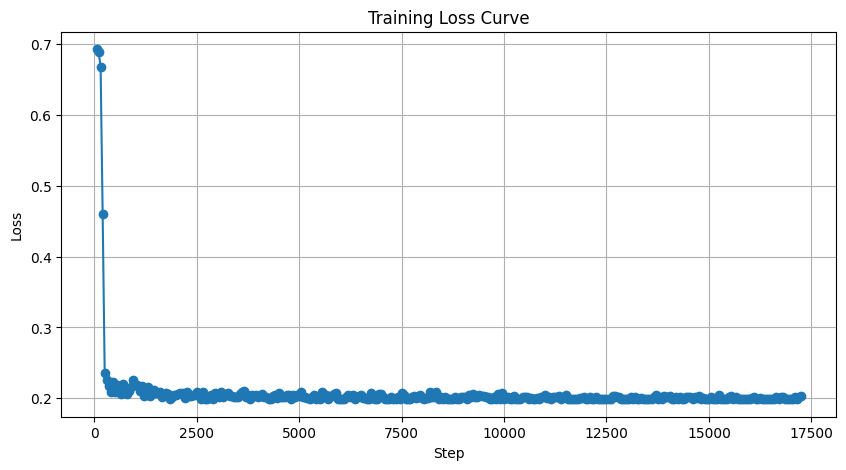

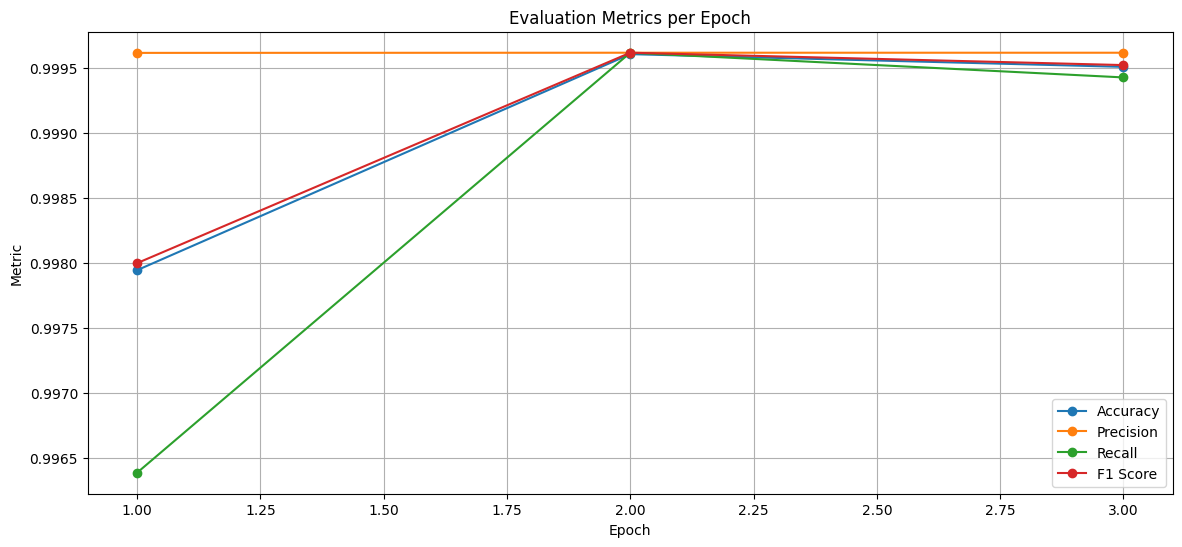

In [12]:
df_logs = pd.DataFrame(trainer.state.log_history)
loss_df = df_logs[df_logs["loss"].notna()]
plt.figure(figsize=(10,5))
plt.plot(loss_df["step"], loss_df["loss"], marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Metrics per epoch
eval_df = df_logs[df_logs["eval_loss"].notna()].copy()
if "epoch" not in eval_df.columns:
    eval_df["epoch"] = range(1, len(eval_df)+1)

plt.figure(figsize=(14,6))
for col, label in [
    ("eval_accuracy", "Accuracy"),
    ("eval_precision", "Precision"),
    ("eval_recall", "Recall"),
    ("eval_f1", "F1 Score")
]:
    if col in eval_df:
        plt.plot(eval_df["epoch"], eval_df[col], marker="o", label=label)

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Evaluation Metrics per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve

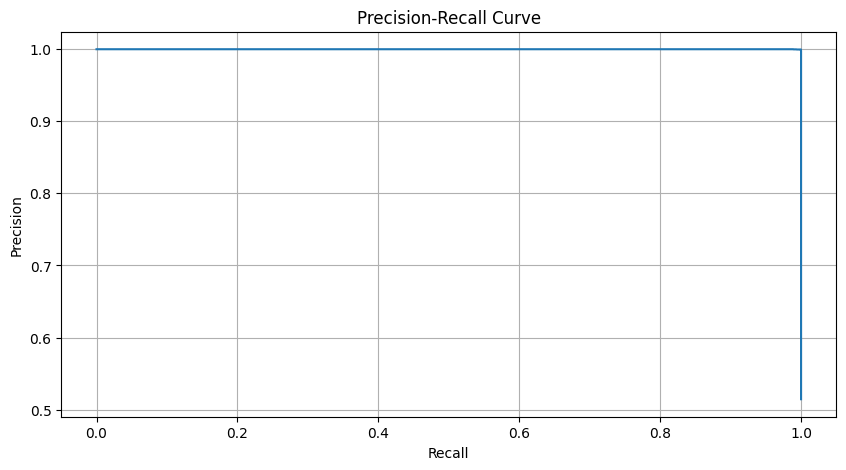

In [13]:
probs = torch.softmax(torch.tensor(preds.predictions), dim=1)[:, 1].numpy()
prec, rec, thresh = precision_recall_curve(y_true, probs)

plt.figure(figsize=(10,5))
plt.plot(rec, prec)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# Classification Report

In [14]:
final_preds = preds.predictions.argmax(-1)
print(classification_report(y_true, final_preds, target_names=["Legit","Phishing"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      4965
    Phishing       1.00      1.00      1.00      5259

    accuracy                           1.00     10224
   macro avg       1.00      1.00      1.00     10224
weighted avg       1.00      1.00      1.00     10224



# Inference Helper

In [44]:
from utils.helpers.preprocess_helper import extract_header_anomalies
def predict_header_eml(eml_path: str):
    loader = EmlLoader()

    # Extract raw header block from EML
    try:
        _, _, headers_raw, canonical_raw = loader.separate_header_blocks(eml_path)
    except:
        return {"error": "Unable to read EML file."}

    if not isinstance(headers_raw, str):
        headers_raw = "" if headers_raw is None else str(headers_raw)

    if not isinstance(canonical_raw, str):
        canonical_raw = "" if canonical_raw is None else str(canonical_raw)

    headers_raw_clean = clean_header(headers_raw)

    parsed = {
        "subject": "",
        "from_email": "",
        "to_email": "",
        "reply_to_email": "",
        "date": "",
        "headers_raw": headers_raw_clean
    }
    anomaly_dict = extract_header_anomalies(parsed)

    # ensure numeric fields exist
    numeric_vals = [
        anomaly_dict["header_from_reply_mismatch"],
        anomaly_dict["header_domain_mismatch"],
        anomaly_dict["header_suspicious_tld"],
        anomaly_dict["header_received_count"],
        anomaly_dict["header_to_anomaly"],
        anomaly_dict["header_x_mailer_anomaly"],
        anomaly_dict["header_date_malformed"],
    ]

    anomaly_text = (
        f"from_reply_mismatch: {numeric_vals[0]} "
        f"domain_mismatch: {numeric_vals[1]} "
        f"suspicious_tld: {numeric_vals[2]} "
        f"received_count: {numeric_vals[3]} "
        f"to_anomaly: {numeric_vals[4]} "
        f"x_mailer_anomaly: {numeric_vals[5]} "
        f"date_malformed: {numeric_vals[6]}"
    )

    header_input = (
        "[RAW]\n" + headers_raw_clean +
        "\n\n[CANONICAL]\n" + canonical_raw +
        "\n\n[ANOMALIES]\n" + anomaly_text
    )

    inputs = tokenizer(
        [header_input],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_tensors="pt"
    ).to(device)
    
    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
        probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred   = int(np.argmax(probs))

    return {
        "prediction": "PHISHING" if pred == 1 else "LEGIT",
        "prob_legit": float(probs[0]),
        "prob_phishing": float(probs[1]),
        "clean_header": headers_raw_clean[:2000],   # optional preview
        "canonical_header": canonical_raw[:2000],   # optional preview
        "anomalies": anomaly_dict
    }


# --- Quick test ---
FILE = "inputs/phish_header.eml"
for key, value in predict_header_eml(FILE).items():
    if key == "anomalies":
        print(f"{key.upper()}: ")
        for anomaly, anomaly_value in value.items():
            print(f"{anomaly}: {anomaly_value}")
    else:
        print(f"{key}: {value}")

prediction: PHISHING
prob_legit: 0.04252295196056366
prob_phishing: 0.9574770927429199
clean_header: From: flthomqm@aol.com
To: felecia.adams@enron.com, gregory.adams@enron.com, glenn.anderson@enron.com, 
Subject: CMS Attack Sample
Content-Type: multipart/signed; protocol="application/x-pkcs7-signature"; micalg="sha-256"; boundary="----"
This is an S/MIME signed message
----
1
Content-Type: text/plain; charset=iso-8859-2
Content-Transfer-Encoding: quoted-printable
canonical_header: From: flthomqm@aol.com
To: felecia.adams@enron.com, gregory.adams@enron.com, glenn.anderson@enron.com, 
Subject: CMS Attack Sample
Content-Type: multipart/signed; protocol="application/x-pkcs7-signature"; micalg="sha-256"; boundary="----5D710E5192338F8D6E1D1324B6443410"
ANOMALIES: 
header_from_reply_mismatch: 0
header_domain_mismatch: 0
header_suspicious_tld: 0
header_received_count: 0
header_to_anomaly: 0
header_x_mailer_anomaly: 1
header_date_malformed: 1
